# Credit Risk / Loan Default Prediction

**Objective:** predict whether a loan applicant will default (`loan_status`) using the credit risk dataset, compare Logistic Regression, XGBoost, Random Forest and AdaBoost, then tune the decision threshold, calibrate the probabilities, explain the model with SHAP, and use the calibrated model for counterfactual analysis, financial stress testing and a final risk decision summary.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    precision_score,
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report,
    roc_auc_score
)

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [2]:
df=pd.read_csv("M:\loanpredictor\credit_risk_dataset.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Dell\AppData\Local\Temp\ipykernel_9576\403042895.py:1: SyntaxWarning: invalid escape sequence '\l'
  df=pd.read_csv("M:\loanpredictor\credit_risk_dataset.csv")


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Initial Data Inspection

In [3]:
df.shape

(32581, 12)

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## 4. Exploratory Data Analysis (EDA)

<Axes: xlabel='loan_status', ylabel='count'>

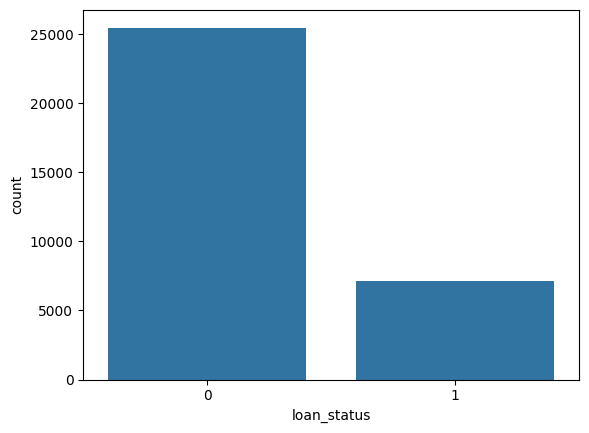

In [8]:
sns.countplot(x='loan_status',data=df)

In [9]:
numerical_col=df.select_dtypes(include=np.number).columns
numerical_col

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

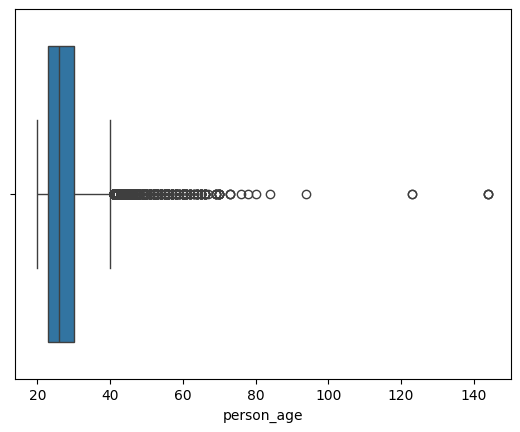

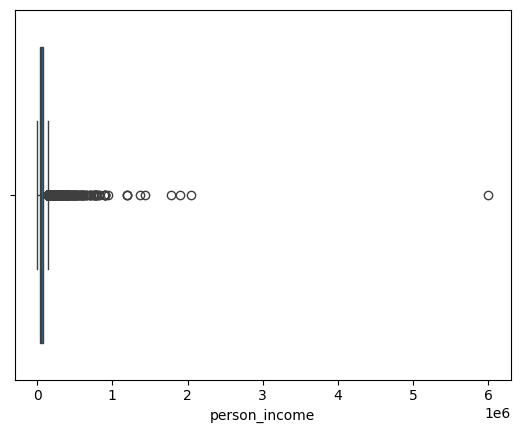

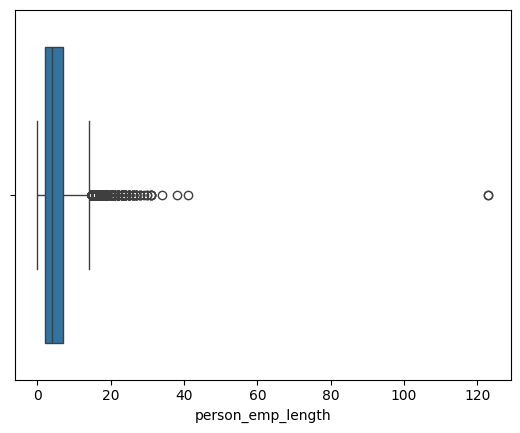

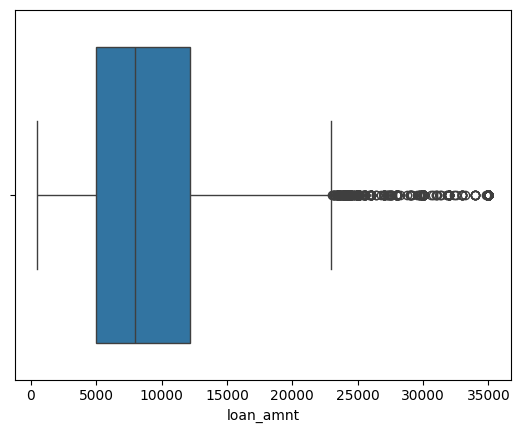

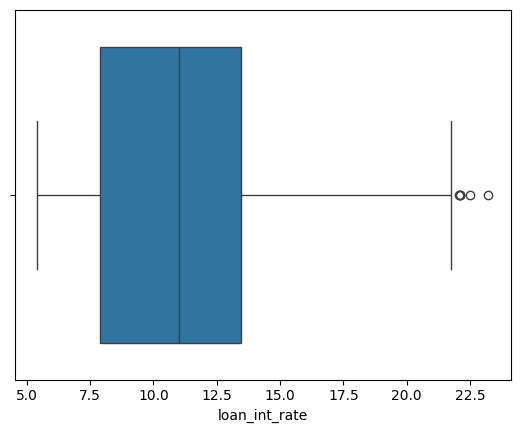

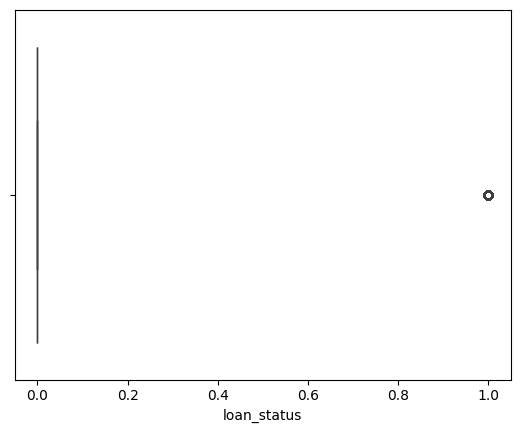

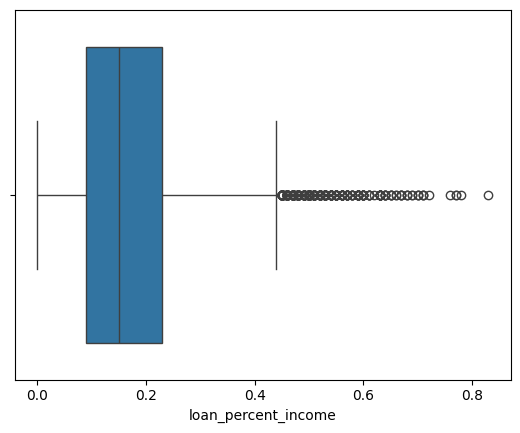

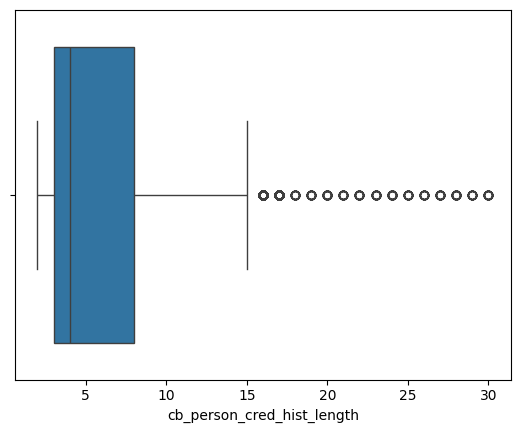

In [10]:
for i in numerical_col:
    sns.boxplot(x=df[i])
    plt.show()


In [11]:
(df['person_age']>100).sum()

np.int64(5)

In [12]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

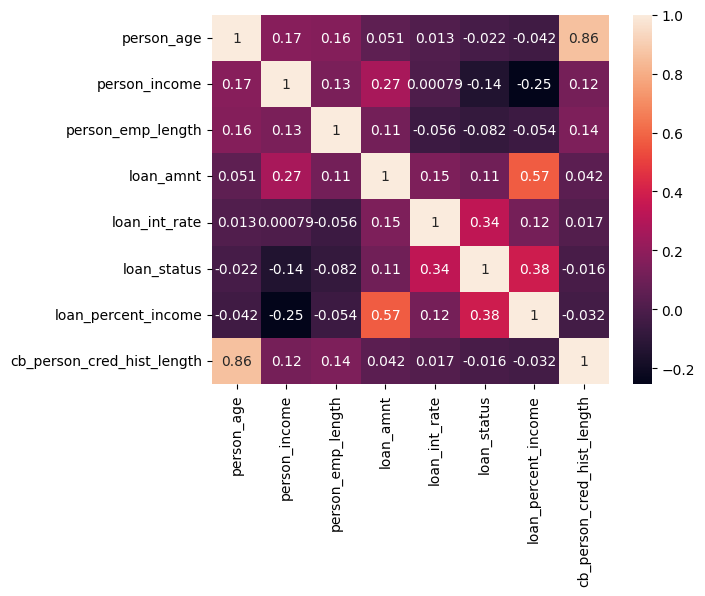

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## 5. Data Cleaning

Data validation and outlier handling.

In [14]:
# Remove duplicate rows
df_copy = df.copy()
df_copy.drop_duplicates(inplace=True)

# Remove unrealistic age
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# Remove unrealistic employment length
df_copy = df_copy[df_copy['person_emp_length'] >= 0]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

# Employment cannot exceed possible working years
df_copy = df_copy[
    df_copy['person_emp_length'] <= df_copy['person_age'] - 18
]

# Loan amount should be positive
df_copy = df_copy[df_copy['loan_amnt'] > 0]

## 6. Features and Target

In [15]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']



In [16]:
X.shape

(23742, 11)

In [17]:
y.shape

(23742,)

### Final feature lists (numerical / categorical)

In [18]:
numerical_cols=['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

categorical_cols=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

## 7. Train-Test Split

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

## 8. Handle Class Imbalance

`scale_weights` is computed here because the XGBoost pipelines further down use it.

In [20]:
#or
y_train.value_counts()

neg,pos=np.bincount(y_train)
scale_weights=neg/pos
scale_weights

np.float64(3.422118742724098)

## 9. Preprocessing Pipelines

### Logistic Regression: impute + scale numeric, impute + one-hot encode categorical

In [ ]:

preprocessor_lr=ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
    ]),numerical_cols),
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))

    ]),categorical_cols)
    ]
)


### XGBoost: impute (no scaling) numeric, impute + one-hot encode categorical

In [22]:
#xgboost=imput+(no scaling),impute+one hot encoding
preprocessor_xg=ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median'))
    ]),numerical_cols),
        ('cat',Pipeline([
            ('impute',SimpleImputer(strategy='constant',fill_value='Missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]),categorical_cols)

    ]
)

### Random Forest

In [23]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### AdaBoost

In [24]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 10. Evaluation Helper Function

In [ ]:


def evaluate_model(model_name,model,X_test,y_test,threshold=None):

    y_pred=model.predict(X_test)
    y_pred_prob=model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred=(y_pred_prob>threshold).astype(int)
    else:
        y_pred=model.predict(X_test)



    accuracy_s=accuracy_score(y_test,y_pred)#overall model's performance
    precision_s=precision_score(y_test,y_pred)#of the ones i picked ,how many were actually right
    
    recall_s=recall_score(y_test,y_pred)#out of everyone that was really there,how much did you manage to find
    f1_s=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)
    class_reort=classification_report(y_test,y_pred)

    print(f"Accuracy: {accuracy_s:.2f}")
    print(f"Precision: {precision_s:.2f}")
    print(f"Recall: {recall_s:.2f}")
    print(f"F_s: {f1_s:.2f}")
    print()

    print(f"{model_name} Classification Report:")
    print(class_reort)


    #plotting confusion matrix
    sns.heatmap(cm,annot=True,fmt="d")

    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()


#plott on roc auc curve
    precison,recall,threshold=precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recall,precison)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()


   



## 11. Model Training, Comparison and Hyperparameter Tuning

### 11.1 Stratified Cross-Validation: Logistic Regression vs XGBoost

In [26]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring={'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}

In [27]:
lr_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced'))


])
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
#xgboost
xgb_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
        n_estimators=300,max_depth=5,learning_rate=0.1,scale_pos_weight=scale_weights,random_state=42,n_jobs=-1
    ))
])



In [29]:
for cv_name,pipe in [("Logistic Regression",lr_cv_pipeline),
                     ("XGBoost",xgb_cv_pipeline)]:
     cv_results = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
     print(cv_name)
     print(f"ROC-AUC:{cv_results['test_roc_auc'].mean()}")
     print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
     print(f"Precision: {cv_results['test_precision'].mean()}")
     print(f"Recall: {cv_results['test_recall'].mean()}")
     print(f"F1: {cv_results['test_f1'].mean()}")

Logistic Regression
ROC-AUC:0.8753430271558479
Accuracy: 0.8156686836326902
Precision: 0.5668918726234831
Recall: 0.7855646100116415
F1: 0.6584226854764679
XGBoost
ROC-AUC:0.9435268382289828
Accuracy: 0.9153896822436435
Precision: 0.8226230226961022
Recall: 0.7981373690337602
F1: 0.8100939018032303


### 11.2 Logistic Regression: Hyperparameter Tuning

`baseline_model` is defined here as the template for the randomized search.

In [30]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [31]:
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

In [32]:
random_search_lr = RandomizedSearchCV(
    estimator=baseline_model,
    param_distributions=param_grid_lr,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

In [33]:
random_search_lr.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length']),
                                                                              ('cat',
                                                                               Pipeline(steps=[...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['person_home_ownership',
                                                                                'loan_intent',
                                                                                'loan_grade',
                                                                                'cb_person_default_on_file'])])),
                                             ('model',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__C': [0.01, 0.1, 1, 10, 100],
                                        'model__class_weight': [None,
                                                                'balanced'],
                                        'model__solver': ['liblinear',
                                                          'lbfgs']},
                   random_state=42, scoring='roc_auc')

In [34]:
random_search_lr.best_params_

{'model__solver': 'liblinear',
 'model__class_weight': 'balanced',
 'model__C': 100}

In [35]:
random_search_lr.best_score_

np.float64(0.875497833432813)

In [36]:
best_lr = random_search_lr.best_estimator_

### 11.3 Baseline Logistic Regression

`baseline_model` is intentionally re-defined (class_weight="balanced") and fitted here. This version is the one used in the model evaluation section.

In [37]:
baseline_model=Pipeline([
    ("preprocessor",preprocessor_lr),
    ("classifier",LogisticRegression(class_weight="balanced"))

])
baseline_model.fit(X_train,y_train)
    

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

### 11.4 XGBoost: Baseline and Hyperparameter Tuning

In [38]:
xg_model=Pipeline([
    ("preprocessor",preprocessor_xg),
    ("classifier",XGBClassifier(scale_pos_weight=scale_weights,learning_rate=0.1,random_state=42))
])
xg_model.fit(X_train,y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constan...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.01, 0.49),
    "classifier__subsample": uniform(0.6, 0.4),  # row sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4),  # column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5)
}

# lower gamma -> high splits -> complex tree -> higher overfitting risk
# higher gamma -> low splits -> simpler tree -> less overfitting risk



In [40]:
random_search=RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,cv=cv,
    scoring="average_precision",
    n_jobs=-1,verbose=1
)

random_search.fit(X_train,y_train)


Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217FB554F50>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217F9BC7B60>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000217FB554B90>},
                   scoring='average_precision', verbose=1)

In [41]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8928738962488207),
 'classifier__gamma': np.float64(0.030122263838281982),
 'classifier__learning_rate': np.float64(0.06712749557200057),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 582,
 'classifier__subsample': np.float64(0.8649301205805601)}

In [42]:
print(f"score after performing tuning: {random_search.best_score_:.2f}")

score after performing tuning: 0.91


Accuracy: 0.93
Precision: 0.86
Recall: 0.81
F_s: 0.83

xgboost Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3675
           1       0.86      0.81      0.83      1074

    accuracy                           0.93      4749
   macro avg       0.90      0.89      0.89      4749
weighted avg       0.93      0.93      0.93      4749



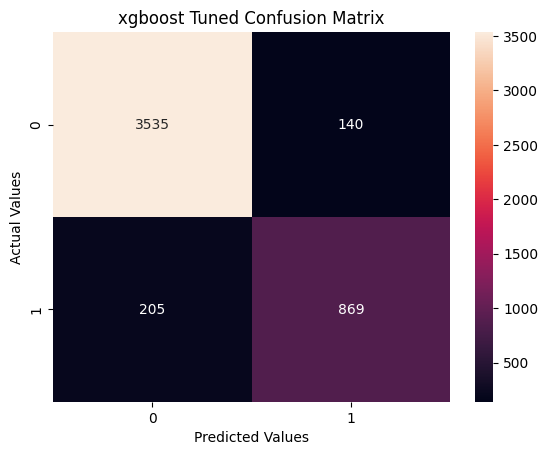

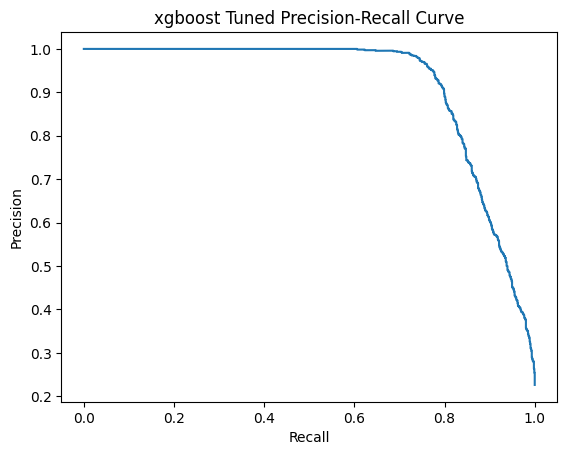

In [43]:
best_xg = random_search.best_estimator_

evaluate_model(
    "xgboost Tuned",
    best_xg,
    X_test,
    y_test
)

### 11.5 Random Forest

In [44]:
rf_model = Pipeline([
    ("preprocessor",preprocessor_rf),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

In [45]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [46]:
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.9355653821857233
Precision: 0.9752475247524752
Recall: 0.7337057728119181
F1: 0.8374070138150903
ROC-AUC: 0.9354115202878173


In [48]:
param_grid_rf = {
    "classifier__n_estimators": randint(100, 500),
    "classifier__max_depth": randint(5, 30),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 10),
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": ["balanced", "balanced_subsample"]
}

In [49]:
random_search_rf=RandomizedSearchCV(
    
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

In [50]:
random_search_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder...
                                        'classifier__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217FA1067A0>,
                                        'classifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217FB5BF1D0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217F9FA3950>},
                   random_state=42, scoring='roc_auc')

In [51]:
random_search_rf.best_params_

{'classifier__class_weight': 'balanced',
 'classifier__max_depth': 19,
 'classifier__max_features': 'sqrt',
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 8,
 'classifier__n_estimators': 108}

In [52]:
print(f"Random forest after hyperparameter tuning: {random_search_rf.best_score_}")

Random forest after hyperparameter tuning: 0.9338200691008636


Accuracy: 0.93
Precision: 0.95
Recall: 0.75
F_s: 0.84

rf Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3675
           1       0.95      0.75      0.84      1074

    accuracy                           0.93      4749
   macro avg       0.94      0.87      0.90      4749
weighted avg       0.94      0.93      0.93      4749



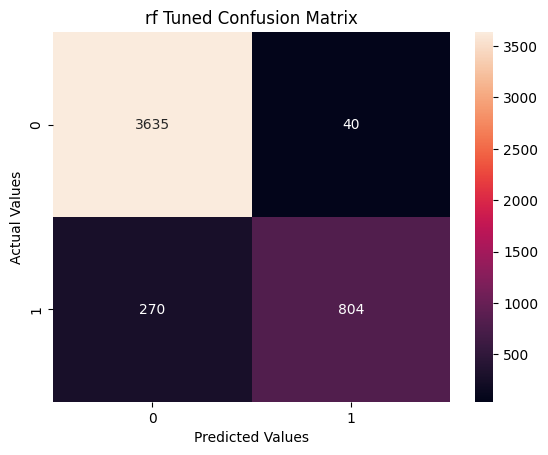

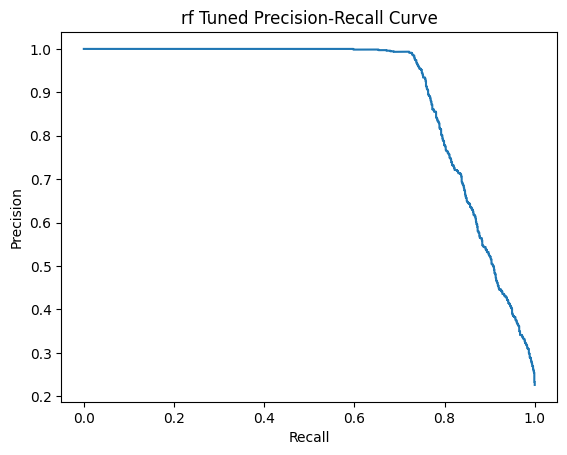

In [53]:
best_rf = random_search_rf.best_estimator_

evaluate_model(
    "rf Tuned",
    best_rf,
    X_test,
    y_test
)

### 11.6 AdaBoost

In [54]:
ada_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(random_state=42))
])

In [55]:
ada_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('classifier', AdaBoostClassifier(random_state=42))])

Accuracy: 0.89
Precision: 0.81
Recall: 0.68
F_s: 0.74

AdaBoost Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3675
           1       0.81      0.68      0.74      1074

    accuracy                           0.89      4749
   macro avg       0.86      0.82      0.84      4749
weighted avg       0.89      0.89      0.89      4749



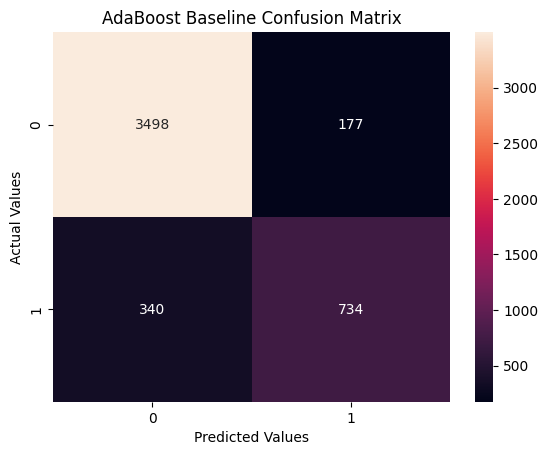

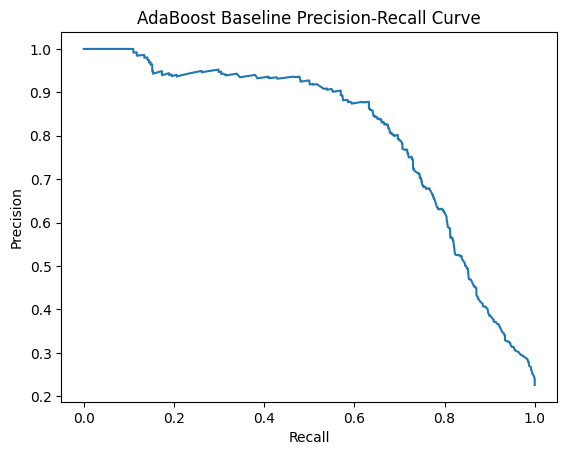

In [56]:
evaluate_model(
    "AdaBoost Baseline",
    ada_model,
    X_test,
    y_test
)

In [57]:
param_grid_ada = {
    "classifier__n_estimators": randint(50, 500),
    "classifier__learning_rate": uniform(0.01, 0.99)
}

In [58]:
random_search_ada = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=param_grid_ada,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search_ada.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                                              (...
      dtype='object'))])),
                                             ('classifier',
                                              AdaBoostClassifier(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000217F9FA1BA0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000217F9BA7CE0>},
                   random_state=42, scoring='roc_auc')

In [59]:
random_search_ada.best_params_

{'classifier__learning_rate': np.float64(0.83045013406041),
 'classifier__n_estimators': 459}

In [60]:
random_search_ada.best_score_

np.float64(0.9014016010725605)

Accuracy: 0.90
Precision: 0.83
Recall: 0.69
F_s: 0.75

AdaBoost Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      3675
           1       0.83      0.69      0.75      1074

    accuracy                           0.90      4749
   macro avg       0.87      0.82      0.84      4749
weighted avg       0.89      0.90      0.89      4749



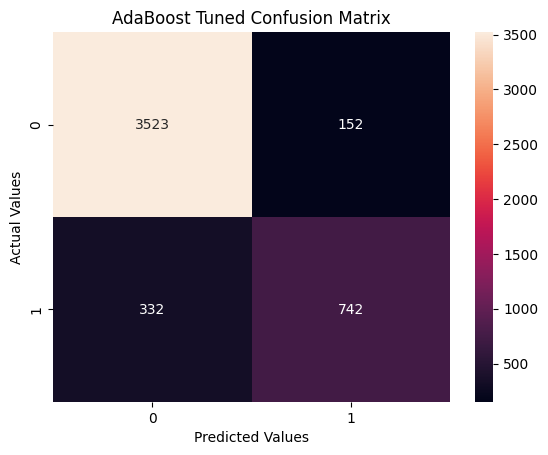

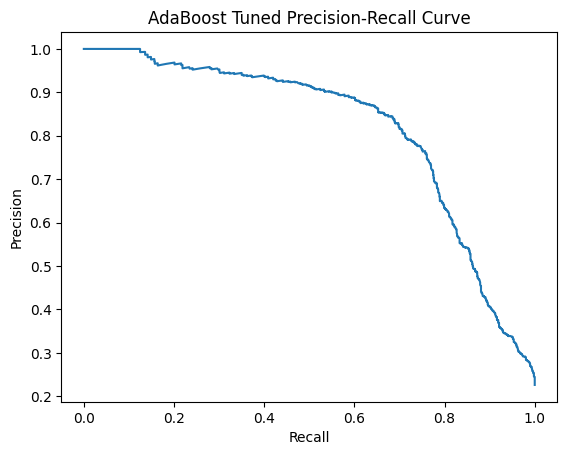

In [61]:
best_ada = random_search_ada.best_estimator_

evaluate_model(
    "AdaBoost Tuned",
    best_ada,
    X_test,
    y_test
)

## 12. Model Evaluation (all models on the test set)

Accuracy: 0.83
Precision: 0.59
Recall: 0.81
F_s: 0.68

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      3675
           1       0.59      0.81      0.68      1074

    accuracy                           0.83      4749
   macro avg       0.76      0.82      0.78      4749
weighted avg       0.86      0.83      0.84      4749



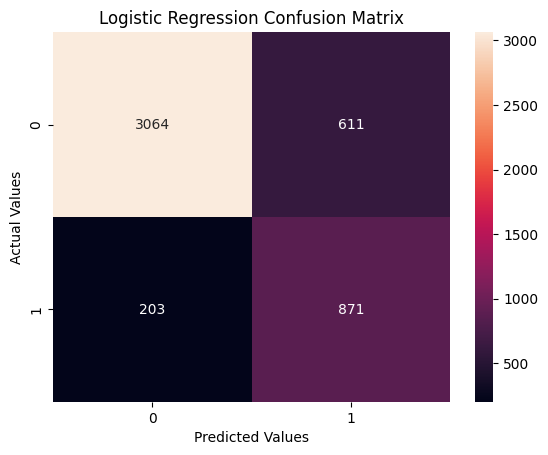

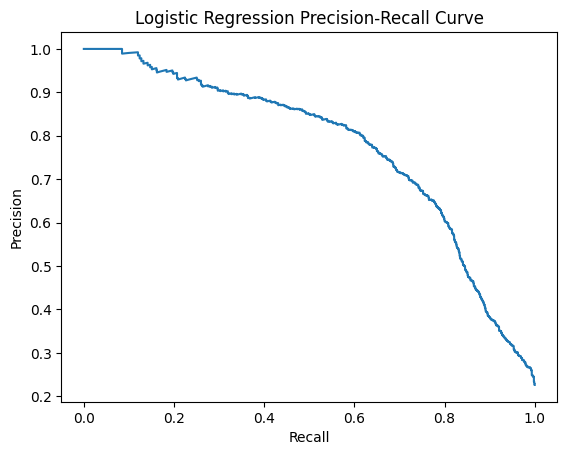

Accuracy: 0.92
Precision: 0.85
Recall: 0.80
F_s: 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3675
           1       0.85      0.80      0.82      1074

    accuracy                           0.92      4749
   macro avg       0.90      0.88      0.89      4749
weighted avg       0.92      0.92      0.92      4749



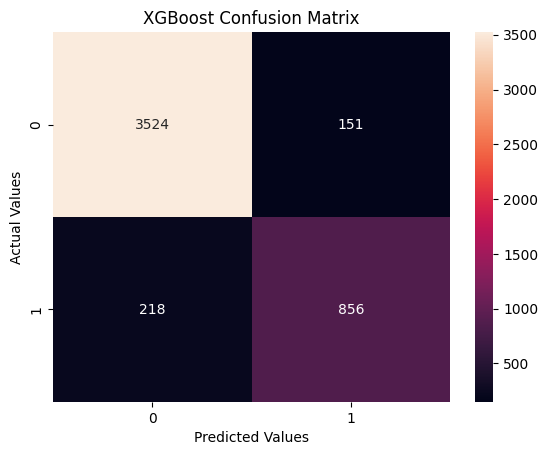

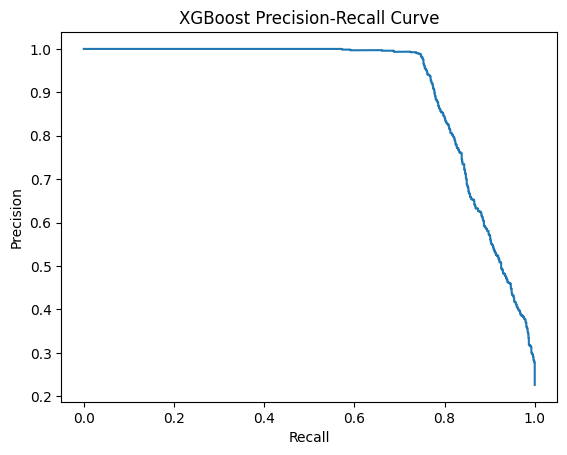

Accuracy: 0.94
Precision: 0.98
Recall: 0.73
F_s: 0.84

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3675
           1       0.98      0.73      0.84      1074

    accuracy                           0.94      4749
   macro avg       0.95      0.86      0.90      4749
weighted avg       0.94      0.94      0.93      4749



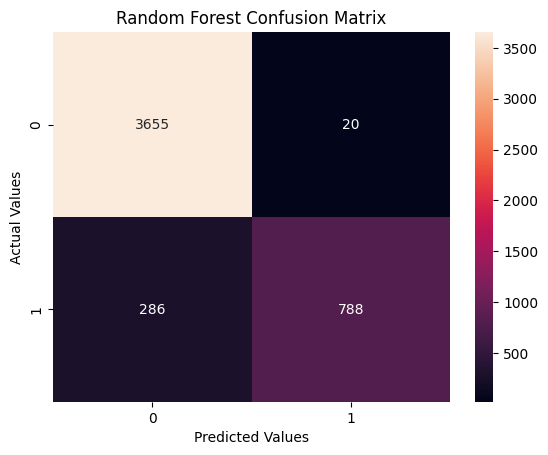

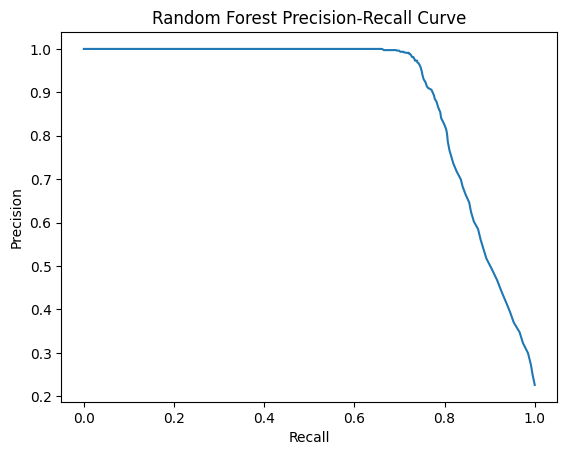

Accuracy: 0.89
Precision: 0.81
Recall: 0.68
F_s: 0.74

AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3675
           1       0.81      0.68      0.74      1074

    accuracy                           0.89      4749
   macro avg       0.86      0.82      0.84      4749
weighted avg       0.89      0.89      0.89      4749



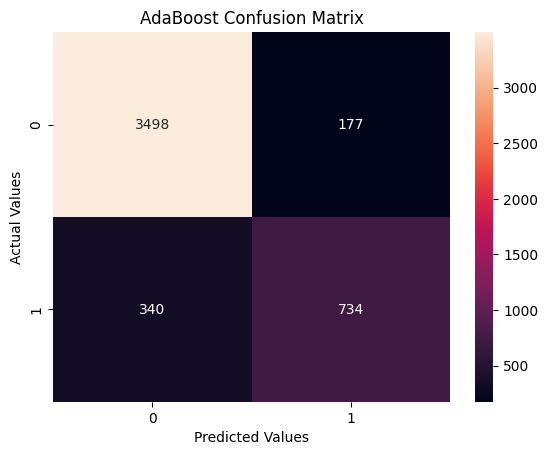

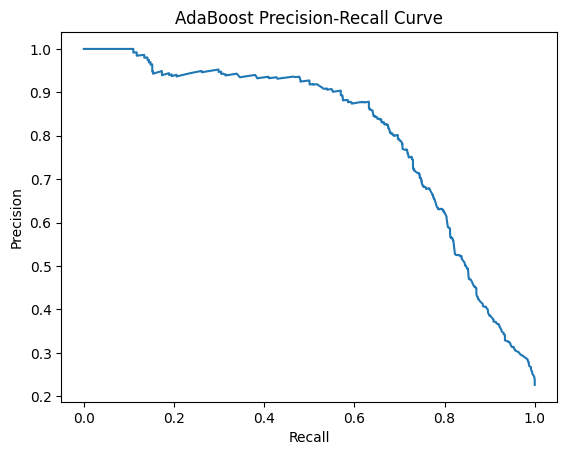

In [62]:
results = []

results.append(evaluate_model(
    "Logistic Regression",
    baseline_model,
    X_test,
    y_test
))

results.append(evaluate_model(
    "XGBoost",
    xg_model,
    X_test,
    y_test
))

results.append(evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
))

results.append(evaluate_model(
    "AdaBoost",
    ada_model,
    X_test,
    y_test
))

Accuracy: 0.83
Precision: 0.59
Recall: 0.81
F_s: 0.68

Tuned Logistic Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88      3675
           1       0.59      0.81      0.68      1074

    accuracy                           0.83      4749
   macro avg       0.76      0.82      0.78      4749
weighted avg       0.86      0.83      0.84      4749



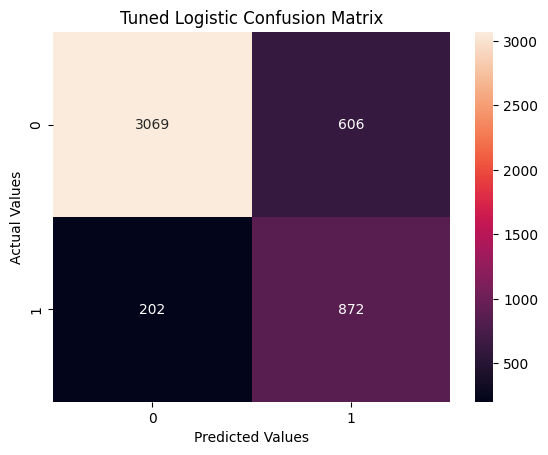

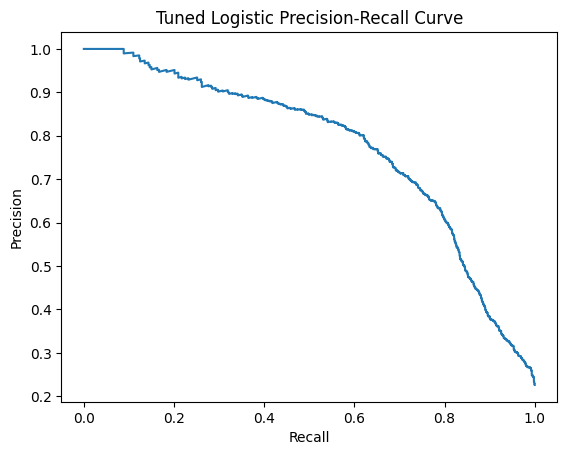

Accuracy: 0.93
Precision: 0.86
Recall: 0.81
F_s: 0.83

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3675
           1       0.86      0.81      0.83      1074

    accuracy                           0.93      4749
   macro avg       0.90      0.89      0.89      4749
weighted avg       0.93      0.93      0.93      4749



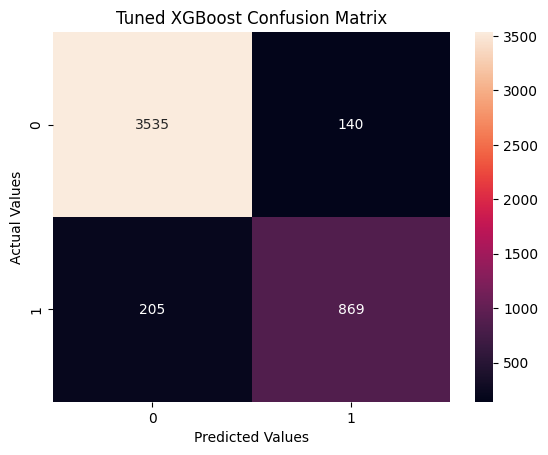

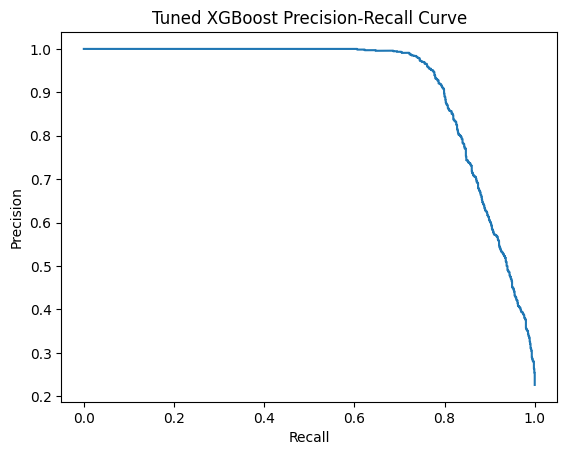

Accuracy: 0.93
Precision: 0.95
Recall: 0.75
F_s: 0.84

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3675
           1       0.95      0.75      0.84      1074

    accuracy                           0.93      4749
   macro avg       0.94      0.87      0.90      4749
weighted avg       0.94      0.93      0.93      4749



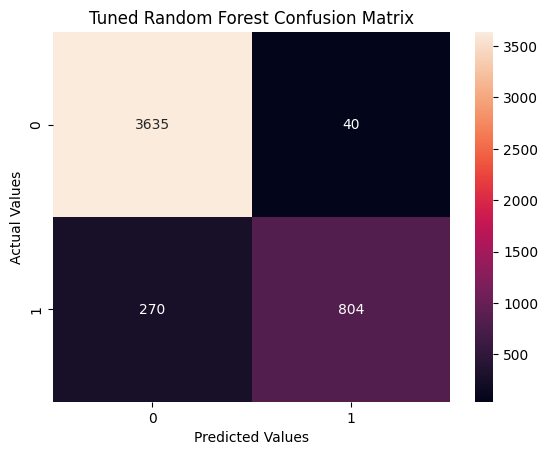

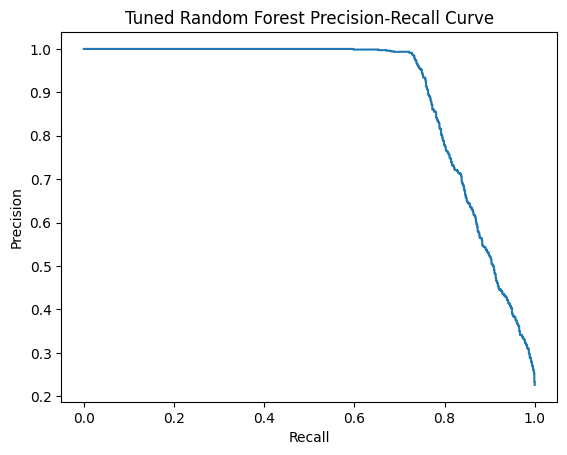

Accuracy: 0.90
Precision: 0.83
Recall: 0.69
F_s: 0.75

Tuned AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      3675
           1       0.83      0.69      0.75      1074

    accuracy                           0.90      4749
   macro avg       0.87      0.82      0.84      4749
weighted avg       0.89      0.90      0.89      4749



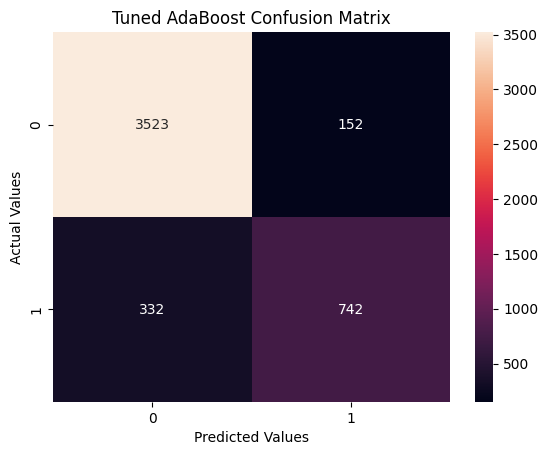

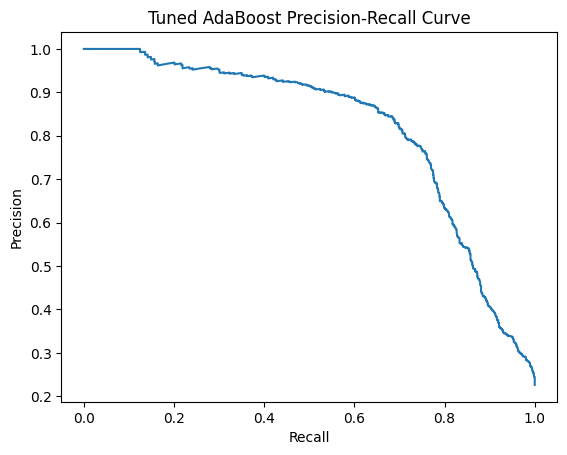

In [63]:
evaluate_model("Tuned Logistic", best_lr, X_test, y_test)

evaluate_model("Tuned XGBoost", best_xg, X_test, y_test)

evaluate_model("Tuned Random Forest", best_rf, X_test, y_test)

evaluate_model("Tuned AdaBoost", best_ada, X_test, y_test)

## 13. Threshold Tuning (XGBoost)

Best Threshold: 0.7313468
Best F1 Score: 0.850928381472598
Accuracy: 0.94
Precision: 0.99
Recall: 0.75
F_s: 0.85

XGBOOST Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3675
           1       0.99      0.75      0.85      1074

    accuracy                           0.94      4749
   macro avg       0.96      0.87      0.91      4749
weighted avg       0.94      0.94      0.94      4749



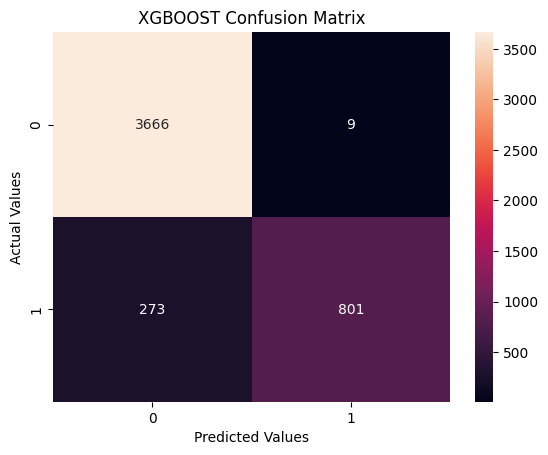

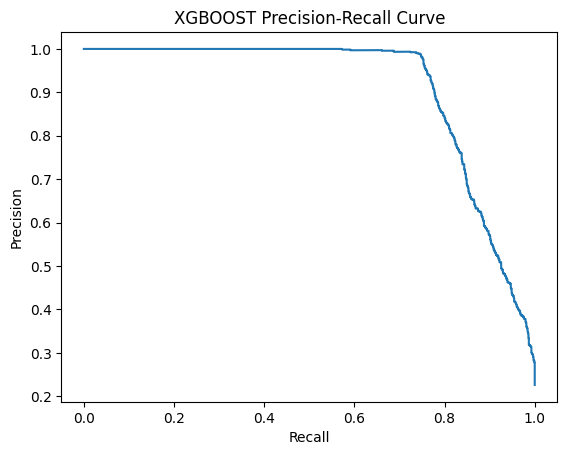

In [64]:
#get the prob of class 1 from xgboost
prob = xg_model.predict_proba(X_test)[:, 1]


#for each threshold calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, prob)


#calculate f1 score for each threshold value
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)


#get the threshold that produces highest f1 score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1[best])


#evaluate xgboost model using that threshold
evaluate_model("XGBOOST", xg_model, X_test, y_test, best_threshold)


## 14. Probability Calibration

In [65]:
"""
Method by which we can fix poorly calibrated model
1.Platt scaling/sigmoid->adjust the probabilities using a sigmoid curve
2.isotonic regression->learn a flexible mapping from old prob.(better prob)(non linear )
3 temperature scaling-> adjust the confidence of neural network prediction using temperature


"""


"""
1.calibrated xgboost model
2.get probabilities
3.create calibration curves
4.plot

"""

'\n1.calibrated xgboost model\n2.get probabilities\n3.create calibration curves\n4.plot\n\n'

In [66]:
#1.calibrated xgboost model
best_model=random_search.best_estimator_
calibrated_model=CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train,y_train)




CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.06712749557200057),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=582,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [67]:
#2.get probabilities
uncalibrated=xg_model.predict_proba(X_test)[:,1]
calibrated=calibrated_model.predict_proba(X_test)[:,1]

In [68]:
#create calibration curves
actual_uncal,predicted_uncal=calibration_curve(y_test,uncalibrated,n_bins=10)



In [69]:
actual_cal,predicted_cal=calibration_curve(y_test,calibrated,n_bins=10)

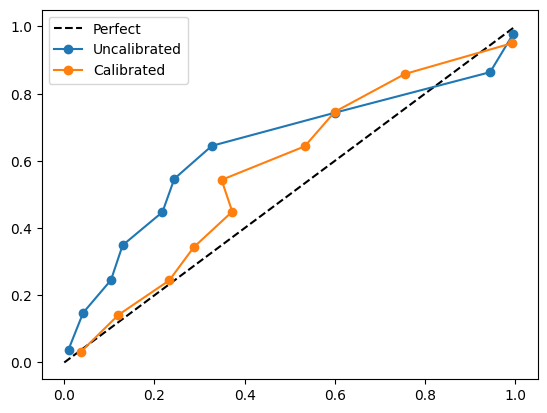

In [70]:
plt.plot([0,1], [0,1], "k--", label="Perfect")

plt.plot(actual_uncal, predicted_uncal,
         marker='o', linestyle='-', label="Uncalibrated")

plt.plot(actual_cal, predicted_cal,
         marker='o', linestyle='-', label="Calibrated")

plt.legend()

## 15. SHAP Explainability (Global and Local)

#SHAP stands for SHapley Additive exPlanations.
#SHAP tells you how each feature contributed
#SHAP tells which features pushed the prediction up or down and how much?


#local explainations-> why did the model made this prediction

#global exlaination-> which feature are genrally most important to the model

In [71]:
#get the trained xgboost classifier model out of the pipeline

xgb_classifier=xg_model.named_steps['classifier']

In [72]:
#transform x_test using the same preprocessing used for training
X_test_transformed=xg_model.named_steps['preprocessor'].transform(X_test)

In [73]:
#get features name after one hot encoding so plots are readable
feature_names=xg_model.named_steps['preprocessor'].get_feature_names_out()

In [74]:
X_test_df=pd.DataFrame(X_test_transformed,columns=feature_names)
X_test_df

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,26.0,55000.0,6.0,6000.0,7.14,0.11,4.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,29.0,40800.0,2.0,3500.0,11.97,0.09,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,40.0,76000.0,1.0,5000.0,13.72,0.07,15.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,22.0,24000.0,3.0,3000.0,11.12,0.13,4.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,32.0,160000.0,2.0,3200.0,11.12,0.02,5.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4744,27.0,69996.0,0.0,6000.0,10.75,0.09,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4745,23.0,27252.0,3.0,5800.0,13.06,0.21,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4746,29.0,35000.0,6.0,4000.0,15.23,0.11,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4747,29.0,120000.0,3.0,6250.0,12.53,0.05,9.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
#create SHAP expaliner built for tree based model
explainer=shap.TreeExplainer(xgb_classifier)

In [76]:
#calculate SHAP  values for every row in the test set
shap_values=explainer.shap_values(X_test_df)
shap_values

array([[-0.04770387, -0.36808267, -0.13038683, ..., -0.01002025,
        -0.01373311,  0.        ],
       [ 0.00477774,  0.06731474,  0.04361807, ..., -0.00843527,
         0.03696355,  0.        ],
       [-0.13994391, -0.24386886,  0.14452218, ..., -0.01071061,
         0.04522223,  0.        ],
       ...,
       [ 0.07190665, -0.06806079, -0.1941263 , ..., -0.00883484,
         0.01688514,  0.        ],
       [-0.01307641, -0.67222124, -0.04627877, ..., -0.00908878,
        -0.0033462 ,  0.        ],
       [ 0.06604902, -0.17785062, -0.06391422, ..., -0.00974241,
        -0.01397634,  0.        ]], shape=(4749, 26), dtype=float32)

global explaination:- this shows which features matters most overall
it also shows if a feature increases or decreases risk

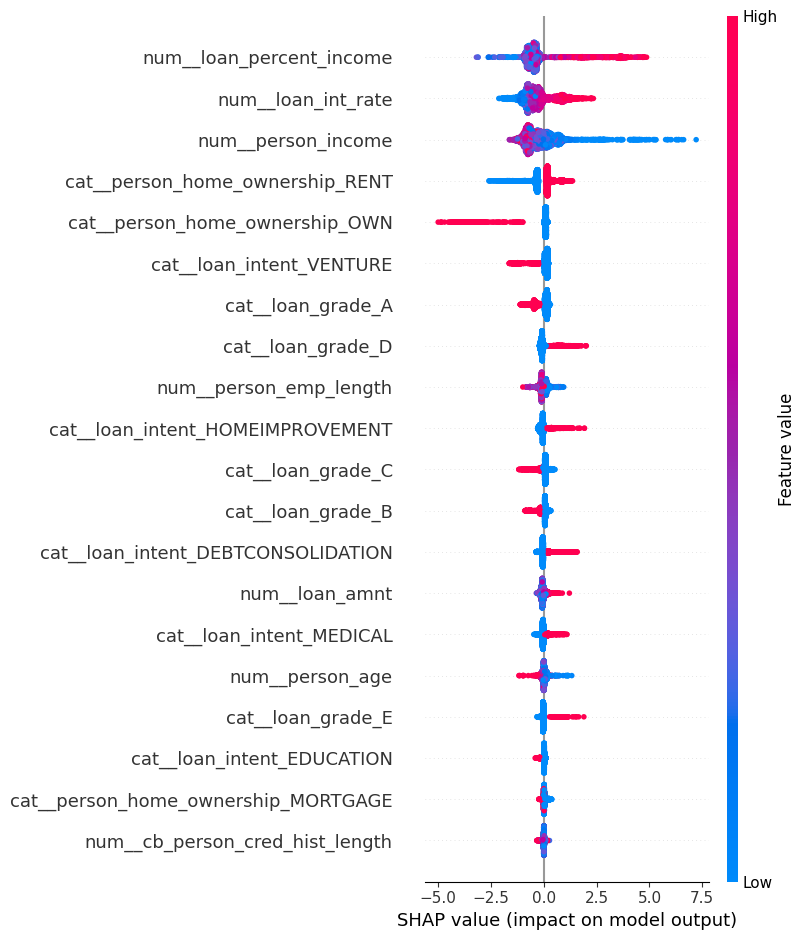

In [77]:
shap.summary_plot(shap_values,X_test_df)

Local explaination: this shows why one specific applicant got their score
it breaks score down feature by feature

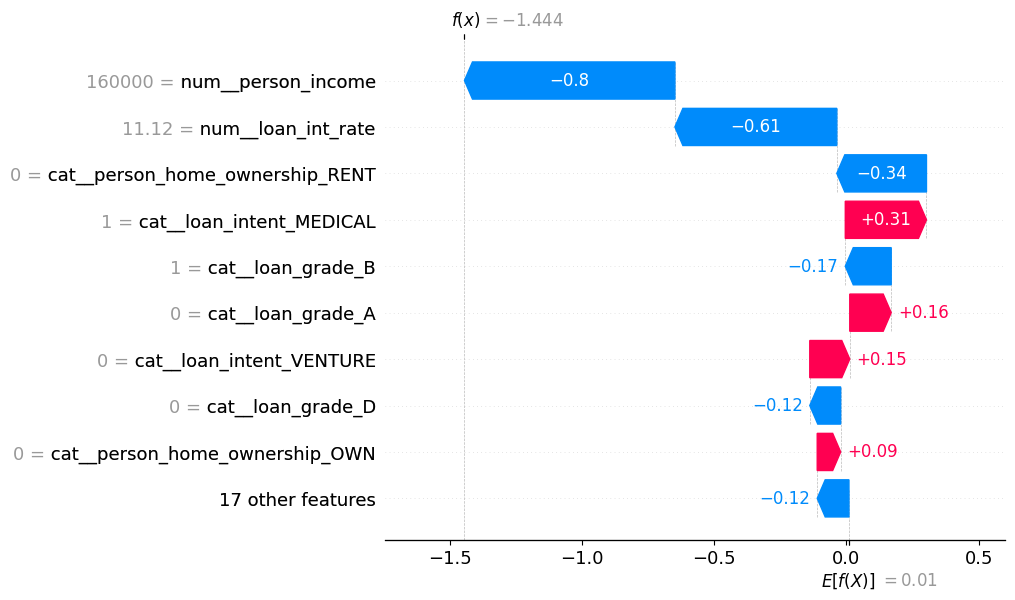

In [78]:
#pick one row to explain,e.g the 4 applicant in the test set
row_index=4

#drawing a waterfall plot showing how each feature pushed the prediction up or down
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[row_index],
        feature_names=feature_names
    )
)

## 16. Error Analysis: False Positives and False Negatives

In [79]:
#false positive are safe people wrongly marked risky
#false negatives are risky people wrongly marked safe



#get pediction from best performing xgboost model for test set
y_pred=random_search.predict(X_test)


In [80]:
#create a dataframe to easily compare the actual and  predicated values

result_df=X_test.copy()
result_df['actual']=y_test
result_df['predicted']=y_pred

In [81]:
#identify FALSE POSITIVE
false_positive=result_df[(result_df['actual']==0) & (result_df['predicted']==1)]

#identify FALSE NEGATIVE
false_negative=result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

In [82]:
print(f"FALSE POSITIVE: {len(false_positive)}")
print(f"FALSE NEGATIVE: {len(false_negative)}")

FALSE POSITIVE: 140
FALSE NEGATIVE: 205


In [83]:
#false negative>false positive

## 17. Counterfactual Risk Simulator

In [84]:
#SELECT APPLICANT
applicant = X_test.iloc[[0]].copy()

current_prob = calibrated_model.predict_proba(applicant)[0, 1]

print("Current Default Risk:", f"{current_prob:.2%}")
print("\nApplicant Details:")
print(applicant.T)

Current Default Risk: 2.83%

Applicant Details:
                                       6678
person_age                               26
person_income                         55000
person_home_ownership                  RENT
person_emp_length                       6.0
loan_intent                 HOMEIMPROVEMENT
loan_grade                                A
loan_amnt                              6000
loan_int_rate                          7.14
loan_percent_income                    0.11
cb_person_default_on_file                 N
cb_person_cred_hist_length                4


In [85]:
#Calculate Current Risk
counterfactual = applicant.copy()

counterfactual["loan_amnt"] = 12000

new_prob = calibrated_model.predict_proba(counterfactual)[0, 1]

print("Original Risk:", f"{current_prob:.2%}")
print("New Risk:", f"{new_prob:.2%}")
print("Risk Change:", f"{(new_prob-current_prob):.2%}")

Original Risk: 2.83%
New Risk: 9.88%
Risk Change: 7.05%


In [86]:
#Define Counterfactual Simulator
def counterfactual_simulator(applicant, calibrated_model):

    current_prob = calibrated_model.predict_proba(applicant)[0, 1]

    scenarios = {
        "Loan Amount +10%": {
            "loan_amnt": applicant["loan_amnt"].iloc[0] * 1.10
        },
        "Loan Amount +20%": {
            "loan_amnt": applicant["loan_amnt"].iloc[0] * 1.20
        },
        "Income +10%": {
            "person_income": applicant["person_income"].iloc[0] * 1.10
        },
        "Income +20%": {
            "person_income": applicant["person_income"].iloc[0] * 1.20
        },
        "Interest Rate +1%": {
            "loan_int_rate": applicant["loan_int_rate"].iloc[0] + 1
        },
        "Interest Rate +2%": {
            "loan_int_rate": applicant["loan_int_rate"].iloc[0] + 2
        },
        "Employment -1 year": {
            "person_emp_length": max(
                0,
                applicant["person_emp_length"].iloc[0] - 1
            )
        },
        "Employment -2 years": {
            "person_emp_length": max(
                0,
                applicant["person_emp_length"].iloc[0] - 2
            )
        }
    }

    results = []

    for scenario_name, changes in scenarios.items():

        scenario = applicant.copy()

        for feature, value in changes.items():
            scenario[feature] = value

        scenario_prob = calibrated_model.predict_proba(scenario)[0, 1]

        results.append({
            "Scenario": scenario_name,
            "Risk": scenario_prob,
            "Risk Change": scenario_prob - current_prob
        })

    results_df = pd.DataFrame(results)

    results_df["Risk"] = results_df["Risk"] * 100
    results_df["Risk Change"] = results_df["Risk Change"] * 100

    return current_prob * 100, results_df

In [87]:
#Run Simulator
current_risk, counterfactual_results = counterfactual_simulator(
    applicant,
    calibrated_model
)

print(f"Current Risk: {current_risk:.2f}%")

counterfactual_results

Current Risk: 2.83%


,Scenario,Risk,Risk Change
0,Loan Amount +10%,3.929406,1.102250
1,Loan Amount +20%,3.486510,0.659354
2,Income +10%,2.045963,-0.781193
3,Income +20%,2.128160,-0.698995
4,Interest Rate +1%,3.276768,0.449613
5,Interest Rate +2%,4.248929,1.421773
6,Employment -1 year,2.916663,0.089507
7,Employment -2 years,2.735241,-0.091915


In [88]:
#Separate Risk Increasing / Decreasing Scenarios
# Sort scenarios by risk change

sorted_results = counterfactual_results.sort_values(
    "Risk Change",
    ascending=False
)

print("🔴 Risk Increasing Scenarios")
print(
    sorted_results[
        sorted_results["Risk Change"] > 0
    ][["Scenario", "Risk", "Risk Change"]]
)

print("\n🟢 Risk Decreasing Scenarios")
print(
    sorted_results[
        sorted_results["Risk Change"] < 0
    ][["Scenario", "Risk", "Risk Change"]]
)

🔴 Risk Increasing Scenarios
             Scenario      Risk  Risk Change
5   Interest Rate +2%  4.248929     1.421773
0    Loan Amount +10%  3.929406     1.102250
1    Loan Amount +20%  3.486510     0.659354
4   Interest Rate +1%  3.276768     0.449613
6  Employment -1 year  2.916663     0.089507

🟢 Risk Decreasing Scenarios
              Scenario      Risk  Risk Change
7  Employment -2 years  2.735241    -0.091915
3          Income +20%  2.128160    -0.698995
2          Income +10%  2.045963    -0.781193


In [89]:
#Identify Most Sensitive Tested Scenarios
highest_risk_scenario = counterfactual_results.loc[
    counterfactual_results["Risk Change"].idxmax()
]

lowest_risk_scenario = counterfactual_results.loc[
    counterfactual_results["Risk Change"].idxmin()
]

print("Most Risk-Increasing Tested Scenario:")
print(
    highest_risk_scenario[
        ["Scenario", "Risk", "Risk Change"]
    ]
)

print("\nLargest Risk-Reducing Tested Scenario:")
print(
    lowest_risk_scenario[
        ["Scenario", "Risk", "Risk Change"]
    ]
)

Most Risk-Increasing Tested Scenario:
Scenario       Interest Rate +2%
Risk                    4.248929
Risk Change             1.421773
Name: 5, dtype: object

Largest Risk-Reducing Tested Scenario:
Scenario       Income +10%
Risk              2.045963
Risk Change      -0.781193
Name: 2, dtype: object


## 18. Financial Stress Testing

In [90]:
#Define Stress Scenarios
stress_scenarios = {
    "Income -10%": {
        "person_income": lambda x: x * 0.90
    },

    "Income -20%": {
        "person_income": lambda x: x * 0.80
    },

    "Interest Rate +2%": {
        "loan_int_rate": lambda x: x + 2
    },

    "Loan Amount +10%": {
        "loan_amnt": lambda x: x * 1.10
    }
}

In [91]:
# Financial Stress Test Function
def financial_stress_test(applicant, calibrated_model):

    current_prob = calibrated_model.predict_proba(applicant)[0, 1]

    results = []

    for scenario_name, changes in stress_scenarios.items():

        stressed_applicant = applicant.copy()

        for feature, change_function in changes.items():
            current_value = stressed_applicant[feature].iloc[0]
            stressed_applicant[feature] = change_function(current_value)

        stress_prob = calibrated_model.predict_proba(
            stressed_applicant
        )[0, 1]

        results.append({
            "Stress Scenario": scenario_name,
            "Risk": stress_prob,
            "Risk Change": stress_prob - current_prob
        })

    results_df = pd.DataFrame(results)

    results_df["Risk"] = results_df["Risk"] * 100
    results_df["Risk Change"] = results_df["Risk Change"] * 100

    return current_prob * 100, results_df

In [92]:
#Run Individual Stress Tests
stress_current_risk, stress_results = financial_stress_test(
    applicant,
    calibrated_model
)

print(f"Current Risk: {stress_current_risk:.2f}%")

stress_results

Current Risk: 2.83%


,Stress Scenario,Risk,Risk Change
0,Income -10%,30.524467,27.697312
1,Income -20%,82.954309,80.127154
2,Interest Rate +2%,4.248929,1.421773
3,Loan Amount +10%,3.929406,1.102250


In [93]:
#Combined Stress Scenario
combined_stress = applicant.copy()

combined_stress["person_income"] = (
    combined_stress["person_income"] * 0.80
)

combined_stress["loan_int_rate"] = (
    combined_stress["loan_int_rate"] + 2
)

combined_stress["loan_amnt"] = (
    combined_stress["loan_amnt"] * 1.10
)

combined_prob = calibrated_model.predict_proba(
    combined_stress
)[0, 1]

print("Current Risk:", f"{current_prob:.2%}")
print("Combined Stress Risk:", f"{combined_prob:.2%}")
print(
    "Risk Change:",
    f"{(combined_prob - current_prob):+.2%}"
)

Current Risk: 2.83%
Combined Stress Risk: 90.72%
Risk Change: +87.89%


## 19. Risk Decision and Final Summary

In [94]:
#risk level function
def get_risk_level(probability):

    if probability < 10:
        return "Low Risk"

    elif probability < 30:
        return "Moderate Risk"

    elif probability < 60:
        return "High Risk"

    else:
        return "Very High Risk"

In [95]:
#risk decision summary function
def create_risk_summary(
    current_risk,
    counterfactual_results,
    stress_results,
    combined_stress_risk
):

    risk_level = get_risk_level(current_risk)

    highest_cf = counterfactual_results.loc[
        counterfactual_results["Risk Change"].idxmax()
    ]

    lowest_cf = counterfactual_results.loc[
        counterfactual_results["Risk Change"].idxmin()
    ]

    highest_stress = stress_results.loc[
        stress_results["Risk Change"].idxmax()
    ]

    print("========== CREDIT RISK DECISION ==========")

    print(f"\nCurrent Risk: {current_risk:.2f}%")
    print(f"Risk Level: {risk_level}")

    print("\n--- Counterfactual Analysis ---")

    print(
        f"Highest Risk-Increasing Scenario: "
        f"{highest_cf['Scenario']} "
        f"({highest_cf['Risk']:.2f}%)"
    )

    print(
        f"Largest Risk-Reducing Scenario: "
        f"{lowest_cf['Scenario']} "
        f"({lowest_cf['Risk']:.2f}%)"
    )

    print("\n--- Stress Testing ---")

    print(
        f"Highest Individual Stress: "
        f"{highest_stress['Stress Scenario']} "
        f"({highest_stress['Risk']:.2f}%)"
    )

    print(
        f"Combined Stress Risk: "
        f"{combined_stress_risk:.2f}%"
    )

    print("\n==========================================")

In [96]:
create_risk_summary(
    current_risk=current_risk,
    counterfactual_results=counterfactual_results,
    stress_results=stress_results,
    combined_stress_risk=combined_prob * 100
)

========== CREDIT RISK DECISION ==========

Current Risk: 2.83%
Risk Level: Low Risk

--- Counterfactual Analysis ---
Highest Risk-Increasing Scenario: Interest Rate +2% (4.25%)
Largest Risk-Reducing Scenario: Income +10% (2.05%)

--- Stress Testing ---
Highest Individual Stress: Income -20% (82.95%)
Combined Stress Risk: 90.72%



SAVE THE FINAL MODEL

In [97]:
import joblib
joblib.dump(calibrated_model,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [99]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)

New threshold: 0.5659529865609031


In [100]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']